# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

Antwoorden:
1. op het begin van het experiment gaat bijna alle toegevoegde energie in het water zitten, hier is nog niet echt sprake van verdamping. dus maken we door de eerste 10 punten een fitlijn, dit is de verwachte trendlijn als alle energie in het water gaat zitten die door de hele proef wordt toegevoegd.
2. omdat op het begin van de proef zowel alle toegevoegde energie in het water is gaan zitten kunnen we het vermogen berekenen met de soortelijke warmte van water en de opwarming over de tien minuten, hiervoor doen we de aanname dat alle toegevoegde energie in de eerste 10 minuten in het water is gaan zitten. Met dit vermogen en de tijd kan je berekenen hieveel energie er in het experiment is gebruikt. De energie die in het water is gaan zitten kan je berekenen met de begin en eindtemperatuur en de soortelijke warmte van water, hierbij is de massa het water wat nog in de bak zit. Om de energie te berekenen die in het verdampte water is gaan zitten gebruik je weer de soortelijke warmte van water en het temperatuurverschil is nu naar 100 graden in plaats van de eindtemperatuur van de bak.

1.3666666668448983


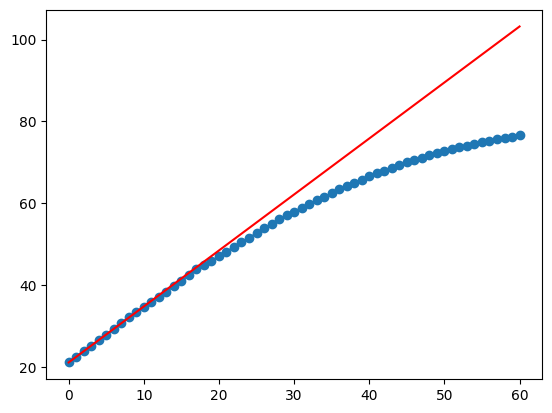

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = np.loadtxt("tempmetingen.csv", delimiter = ';', skiprows = 1)
data = data.T
tijd = data[0]
temp = data[1]

def verwachte_trend(x,a,b):
    return a*x + b

popt, pcov = curve_fit(verwachte_trend, tijd[:10], temp[:10])
a = popt[0]
tijd_test = np.linspace(0, tijd[-1], 1000)
temp_test = verwachte_trend(tijd_test, *popt)
print (a)
plt.plot(tijd, temp, marker='o', linestyle='-')
plt.plot(tijd_test, temp_test, color='red', label='Verwachte trend')

In [4]:
c_w = 4186 #J/kgK
m_water_start = 1.2929 - 0.8208 #kg
m_water_verd = 1.2929 - 1.2749 #kg
m_water_verw = m_water_start - m_water_verd
temp_voor = temp[0]
temp_na = temp[10]
delta_temp = temp_na - temp_voor
delta_temp_verd = 100 - temp_voor
delta_temp_verw = temp[-1] - temp_voor
Q = c_w * m_water_start * delta_temp
#Q is nu de hoeveelheid warmte die is opgenomen door het water in de eerste 10 minuten, om naar vermogen te gaan deel je het door de tijd
W = Q / 600 #Watt
print ("Door de eerste 10 punten te bekijken als dat er geen water verdampt hebben we een vermogen van", W, 'Watt')

en_verd = c_w * m_water_verd * delta_temp_verd
en_verw = c_w * m_water_verw * delta_temp_verw
en_toegevoerd = W * tijd[-1]*60
tot_en = en_verd + en_verw


print ("De totale energie die is gaan zitten in het verdampen en opwarmen van het water is ", tot_en, ' J')
print ("De hoeveelheid energie die is toegevoegd in de proef is ", en_toegevoerd, " J")

Door de eerste 10 punten te bekijken als dat er geen water verdampt hebben we een vermogen van 44.46473850000001 Watt
De totale energie die is gaan zitten in het verdampen en opwarmen van het water is  111245.21043999998  J
De hoeveelheid energie die is toegevoegd in de proef is  160073.05860000002  J


Antwoord opgave 2:
We zien hierboven dat de energie die is gaan zitten in het verdampen en verwarmen van het water een flink stuk lager ligt dan de totaal toegevoegde energie. Deze corresponderen dus niet met elkaar en maakt duidelijk dat er sprake is van energieverlies, dit kan bijvoorbeeld komen door het warmteverlies wat heeft opgetreden tussen het water en de buitenlucht.

Antwoord opgave 3:
Om warmteverlies aan de buitenlucht zo goed mogelijk te voorkomen zou de waterbak met het water beter geïsoleerd kunnen worden, hierdoor blijft meer energie in het water zitten en wordt het water effectiever opgewarmd.